In [21]:
# Install/upgrade required packages (run once) - PyTorch 2.9.1 + CUDA 12.6
!pip install --quiet --upgrade --no-warn-script-location torch==2.9.1+cu126 torchvision==0.24.1+cu126 torchaudio==2.9.1+cu126 --extra-index-url https://download.pytorch.org/whl/cu126
!pip install --quiet --upgrade --no-warn-script-location timm albumentations "datasets[vision]" huggingface_hub torchmetrics scikit-learn opencv-python-headless matplotlib seaborn pandas tqdm

In [22]:
# Check packages and CUDA version
import torch
print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))
else:
    print('gpu: (none)')

torch: 2.9.1+cu126
cuda available: True
gpu: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
# (Optional) Log in to HuggingFace (skip for public datasets)
try:
    from huggingface_hub import login
    login()
except Exception as e:
    print('Skipping HuggingFace login:', repr(e))

In [23]:
# (Optional) Verify login
try:
    from huggingface_hub import whoami
    print(whoami())
except Exception as e:
    print('Not logged in / cannot verify:', repr(e))

{'type': 'user', 'id': '696159abaa6b67e1b6bf7790', 'name': 'infinityxr9', 'fullname': 'Aryan Sisodiya', 'email': 'aryansisodiya091107@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1769904000, 'isPro': False, 'avatarUrl': '/avatars/3f0547d01959ef03971434d884a9641f.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'ps1', 'role': 'read', 'createdAt': '2026-01-09T19:51:02.375Z'}}}


# Galaxy Morphology Classifier — SPACECODE 2026 (Problem-1)

## Overview
This notebook implements a complete **reproducible research pipeline** for classifying galaxy morphologies using deep learning. The dataset contains 256×256 RGB images of galaxies across 10 morphological classes from the HuggingFace repository `Xanadu00/autotrain-data-galaxy_classification`.

## Pipeline Structure
1. **Data Loading & Preprocessing** - Load dataset, analyze class distribution, compute class weights for imbalanced data
2. **Augmentation** - Apply Albumentations transforms (rotation, flipping, cropping, brightness, noise)
3. **Model Architecture** - Pretrained ConvNeXt-Tiny with custom classification head
4. **Training** - Mixed precision training with weighted loss, cosine learning rate scheduling, and early stopping
5. **Evaluation** - Confusion matrix, per-class metrics (precision, recall, F1), ROC-AUC
6. **Robustness Testing** - Evaluate model performance under realistic image corruptions (blur, noise, compression)

## Requirements
- GPU with CUDA support (recommended)
- Python 3.8+
- Internet connection for downloading dataset and pretrained weights

**Note:** All random seeds are fixed for reproducibility.

In [35]:
# Imports and reproducibility setup
import os, random, time
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.utils.class_weight import compute_class_weight
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Reproducibility seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Determinism notes:
# - Full determinism on CUDA may require CUBLAS_WORKSPACE_CONFIG and can reduce performance.
# - For a notebook pipeline, it's better to avoid hard-failing training when that env var isn't set.
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
try:
    torch.use_deterministic_algorithms(False)
except Exception:
    pass
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Device: cuda
PyTorch version: 2.9.1+cu126
CUDA available: True


In [25]:
# Safe defaults (set only if missing) — run after imports
try:
    BATCH_SIZE
except NameError:
    BATCH_SIZE = 32
try:
    IMG_SIZE
except NameError:
    IMG_SIZE = 256
try:
    NUM_CLASSES
except NameError:
    NUM_CLASSES = 10
try:
    EPOCHS
except NameError:
    EPOCHS = 20
try:
    save_path
except NameError:
    save_path = 'best_model.pth'

print('Safe defaults ensured: ', dict(BATCH_SIZE=BATCH_SIZE, IMG_SIZE=IMG_SIZE, NUM_CLASSES=NUM_CLASSES, EPOCHS=EPOCHS, save_path=save_path))

Safe defaults ensured:  {'BATCH_SIZE': 32, 'IMG_SIZE': 256, 'NUM_CLASSES': 10, 'EPOCHS': 20, 'save_path': 'best_model.pth'}


In [26]:
# 1) Data: load HF dataset, compute class distribution and class weights
DATASET_ID = 'Xanadu00/autotrain-data-galaxy_classification'
ds = load_dataset(DATASET_ID, download_mode="reuse_cache_if_exists")
# Inspect splits
print(ds)
# Convert to train/validation if present; otherwise split train
if 'train' in ds and 'validation' in ds:
    ds_train = ds['train']
    ds_val = ds['validation']
else:
    ds = ds['train'].train_test_split(test_size=0.2, seed=SEED)
    ds_train = ds['train']
    ds_val = ds['test']
# Show class distribution
train_labels = np.array(ds_train['label'])
unique, counts = np.unique(train_labels, return_counts=True)
print('Train class distribution:')
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c}')
# Compute class weights (for weighted CE)
classes = np.unique(train_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print('Class weights:', class_weights)

Resolving data files:   0%|          | 0/28382 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/3551 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/3548 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/28376 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3548 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3548 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 28376
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 3548
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 3548
    })
})
Train class distribution:
  Class 0: 3284
  Class 1: 540
  Class 2: 1740
  Class 3: 2964
  Class 4: 2268
  Class 5: 3178
  Class 6: 2996
  Class 7: 4324
  Class 8: 4168
  Class 9: 2914
Class weights: tensor([0.8641, 5.2548, 1.6308, 0.9574, 1.2511, 0.8929, 0.9471, 0.6562, 0.6808,
        0.9738], device='cuda:0')


## 1. Data Pipeline

### Dataset
Loading the galaxy classification dataset from HuggingFace. The dataset contains astronomical images of galaxies labeled by morphological type (spiral, elliptical, irregular, etc.).

### Class Imbalance Handling
Computing class weights using sklearn's `compute_class_weight` with the 'balanced' strategy. This ensures that minority classes receive higher weights during training, preventing the model from being biased towards majority classes.

### Augmentation Strategy
**Training augmentations:**
- **RandomRotate90**: Galaxies have rotational symmetry
- **Flip**: Horizontal/vertical flipping preserves galaxy properties
- **RandomResizedCrop**: Slight scale variations simulate different observation distances
- **RandomBrightnessContrast**: Mimics varying telescope exposure and atmospheric conditions
- **GaussNoise**: Models sensor noise in astronomical imaging

**Validation/Test transforms:**
- Simple resize and normalization (no augmentation to ensure consistent evaluation)

In [27]:
# Albumentations transforms
import os
IMG_SIZE = 256
train_transforms = A.Compose([
    A.RandomRotate90(),
    A.Flip(p=0.5),
    A.RandomResizedCrop(IMG_SIZE, IMG_SIZE, scale=(0.9,1.0), ratio=(0.95,1.05), p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),
    A.Normalize(),
    ToTensorV2(),
])
val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2(),
])
# PyTorch Dataset wrapper for HuggingFace dataset
class HFDataset(Dataset):
    def __init__(self, hf_dataset, transforms=None):
        self.ds = hf_dataset
        self.transforms = transforms
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[int(idx)]
        img = np.array(item['image'])
        if self.transforms:
            img = self.transforms(image=img)['image']
        label = int(item['label'])
        return img, label
# Dataloaders
BATCH_SIZE = 32
train_dataset = HFDataset(ds_train, transforms=train_transforms)
val_dataset = HFDataset(ds_val, transforms=val_transforms)

# Windows notebooks are much more stable with num_workers=0
NUM_WORKERS = 0 if os.name == 'nt' else 4
PIN_MEMORY = (device.type == 'cuda')
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
 )
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
 )
print('Train samples:', len(train_dataset), 'Val samples:', len(val_dataset))
print('NUM_WORKERS:', NUM_WORKERS, 'PIN_MEMORY:', PIN_MEMORY)

Train samples: 28376 Val samples: 3548
NUM_WORKERS: 0 PIN_MEMORY: True


In [32]:
# 2) Model: create timm model with custom head
import timm
import torch.nn as nn

MODEL_NAME = 'convnext_tiny'  # or 'efficientnet_b2'
NUM_CLASSES = 10

# Load pretrained model backbone
try:
    model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=0)
except Exception as e:
    print('WARNING: Could not download pretrained weights (network/DNS issue).')
    print('Falling back to pretrained=False. Error was:', repr(e))
    model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=0)

feature_dim = int(getattr(model, 'num_features', 768))
print(f'Model: {MODEL_NAME}')
print(f'Feature dimension: {feature_dim}')

# Custom head that is robust to ConvNeXt feature-map tensors (B, C, H, W)
class CustomHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout=0.4):
        super().__init__()
        self.in_features = int(in_features)
        self.head = nn.Sequential(
            nn.Linear(self.in_features, self.in_features),
            nn.BatchNorm1d(self.in_features),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(self.in_features, num_classes),
        )
    def forward(self, x):
        # timm ConvNeXt passes feature maps into `head` by default: (B, C, H, W).
        # We do global average pooling so the Linear layers see (B, C).
        if x.ndim == 4:
            x = x.mean(dim=(2, 3))
        elif x.ndim == 3:
            x = x.mean(dim=1)
        return self.head(x)

# Attach custom head to model
model.head = CustomHead(feature_dim, NUM_CLASSES)
model = model.to(device)

print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Model: convnext_tiny
Feature dimension: 768

Total parameters: 28,418,410
Trainable parameters: 28,418,410


In [33]:
# Smoke-test: one forward pass to validate tensor shapes
model.eval()
images, labels = next(iter(train_loader))
images = images.to(device)
with torch.no_grad():
    with autocast_ctx() if 'autocast_ctx' in globals() else nullcontext():
        out = model(images)
print('batch images:', tuple(images.shape))
print('logits:', tuple(out.shape))

batch images: (32, 3, 256, 256)
logits: (32, 10)


## 2. Model Architecture

### Base Model: ConvNeXt-Tiny
ConvNeXt is a modern CNN architecture that incorporates design principles from Vision Transformers while maintaining the efficiency of convolutional networks. It's particularly well-suited for image classification tasks with limited training data due to strong pretrained representations.

**Key advantages:**
- Pretrained on ImageNet-1K (1.28M images, 1000 classes)
- Efficient architecture with ~28M parameters
- Better feature extraction than older architectures (ResNet, EfficientNet)
- Good balance between accuracy and inference speed

### Custom Classification Head
Replacing the standard linear classifier with a more sophisticated head:
- **Linear layer**: Projects features to same dimension for stability
- **BatchNorm1d**: Normalizes activations, helps training stability
- **GELU**: Smooth non-linearity (better than ReLU for fine-grained classification)
- **Dropout (0.4)**: Prevents overfitting on the relatively small galaxy dataset
- **Linear layer**: Final projection to 10 classes

This design provides better regularization and feature refinement than a single linear layer.

In [37]:
# 3) Training setup: loss, optimizer, scheduler, mixed precision (AMP)
from contextlib import nullcontext
import torch.nn.functional as F
from sklearn.metrics import precision_recall_fscore_support

# Weighted cross-entropy loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
EPOCHS = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# AMP configuration (avoid deprecation warnings across torch versions)
amp_enabled = (device.type == 'cuda')
if amp_enabled:
    autocast_ctx = None
    scaler = None
    try:
        from torch.amp import autocast as _autocast, GradScaler as _GradScaler
        try:
            scaler = _GradScaler('cuda')
        except TypeError:
            scaler = _GradScaler()
        def autocast_ctx():
            try:
                return _autocast(device_type='cuda', dtype=torch.float16)
            except TypeError:
                return _autocast()
    except Exception:
        from torch.cuda.amp import autocast as _autocast, GradScaler as _GradScaler
        scaler = _GradScaler()
        def autocast_ctx():
            return _autocast()
else:
    scaler = None
    def autocast_ctx():
        return nullcontext()

# Early stopping parameters
best_val_f1 = -1.0
patience = 5
patience_counter = 0
save_path = 'best_model.pth'

print('Training configuration:')
print('  Device:', device)
print('  AMP enabled:', amp_enabled)
print('  Optimizer: AdamW (lr=1e-4, weight_decay=1e-4)')
print('  Loss: Weighted CrossEntropyLoss')
print('  Scheduler: CosineAnnealingLR')
print(f'  Early stopping: patience={patience}, metric=validation macro-F1')
print(f'  Max epochs: {EPOCHS}')
print('  Checkpoint path:', save_path)

Training configuration:
  Device: cuda
  AMP enabled: True
  Optimizer: AdamW (lr=1e-4, weight_decay=1e-4)
  Loss: Weighted CrossEntropyLoss
  Scheduler: CosineAnnealingLR
  Early stopping: patience=5, metric=validation macro-F1
  Max epochs: 20
  Checkpoint path: best_model.pth


In [30]:
# Helper functions (must run before training/evaluation)
def evaluate_model(model, loader, device):
    """Evaluate model and return (preds, probs, targets)."""
    model.eval()
    all_preds, all_probs, all_targets = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            with autocast_ctx():
                outputs = model(images)
                probs = F.softmax(outputs, dim=1)
            all_preds.append(outputs.argmax(dim=1).cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_targets.append(labels.cpu().numpy())
    preds = np.concatenate(all_preds)
    probs = np.concatenate(all_probs)
    targets = np.concatenate(all_targets)
    return preds, probs, targets

def compute_macro_f1(preds, targets):
    """Compute macro-averaged F1 score."""
    _, _, f1_scores, _ = precision_recall_fscore_support(
        targets, preds, average=None, zero_division=0
    )
    return float(np.mean(f1_scores))

print('Helper functions ready:', evaluate_model.__name__, compute_macro_f1.__name__)

Helper functions ready: evaluate_model compute_macro_f1


### Robustness Analysis Interpretation

**Key insights from robustness testing:**

1. **Most vulnerable corruption** - The corruption type with the largest macro-F1 drop indicates which image degradation most affects the model's learned features.

2. **Most robust classes** - Classes with minimal F1 drops rely on features that are preserved under corruption (e.g., large-scale morphology, overall shape).

3. **Most vulnerable classes** - Classes with large drops depend on fine details that are corrupted (e.g., spiral arms, small-scale texture, color gradients).

4. **Relative performance** - If all classes drop similarly, the model uses global features. If drops vary widely, the model uses class-specific feature types (some fragile, some robust).

### Recommendations for Improvement
- **For blur sensitivity**: Add more blur augmentation during training, or use deconvolution preprocessing
- **For noise sensitivity**: Train with heavier noise augmentation, or use denoising autoencoders
- **For compression sensitivity**: Include JPEG compression in training augmentation pipeline
- **General**: Ensemble models trained on different augmentation strategies

In [38]:
# 4) Training loop with early stopping + checkpointing
from tqdm.auto import tqdm

# If you changed the model definition, make sure optimizer is bound to current parameters.
def _optimizer_matches_model(opt, mdl):
    try:
        opt_param_ids = {id(p) for g in opt.param_groups for p in g.get('params', [])}
        mdl_param_ids = {id(p) for p in mdl.parameters() if p.requires_grad}
        return mdl_param_ids.issubset(opt_param_ids)
    except Exception:
        return False

if 'optimizer' not in globals() or not _optimizer_matches_model(optimizer, model):
    print('Reinitializing optimizer/scheduler (model parameters changed).')
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

training_history = {'train_loss': [], 'val_f1': [], 'lr': []}
print('Starting training...\n')

# Optional quick debug: set MAX_STEPS_PER_EPOCH to a small int (e.g., 20)
MAX_STEPS_PER_EPOCH = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    num_samples = 0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False)
    for step, (images, labels) in enumerate(pbar, start=1):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast_ctx():
            outputs = model(images)
            loss = criterion(outputs, labels)
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        batch_size = images.size(0)
        epoch_loss += loss.item() * batch_size
        num_samples += batch_size
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        if MAX_STEPS_PER_EPOCH is not None and step >= MAX_STEPS_PER_EPOCH:
            break
    avg_train_loss = epoch_loss / max(1, num_samples)
    # Validation
    val_preds, val_probs, val_targets = evaluate_model(model, val_loader, device)
    val_macro_f1 = compute_macro_f1(val_preds, val_targets)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    training_history['train_loss'].append(avg_train_loss)
    training_history['val_f1'].append(val_macro_f1)
    training_history['lr'].append(current_lr)
    print(f'Epoch {epoch}/{EPOCHS}: train_loss={avg_train_loss:.4f}  val_macro_f1={val_macro_f1:.4f}  lr={current_lr:.6f}')
    # Early stopping
    if val_macro_f1 > best_val_f1 + 1e-5:
        best_val_f1 = val_macro_f1
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_f1': best_val_f1,
            'training_history': training_history,
        }, save_path)
        print(f'  ✓ checkpoint saved ({save_path})')
    else:
        patience_counter += 1
        print(f'  no improvement ({patience_counter}/{patience})')
        if patience_counter >= patience:
            print(f'\nEarly stopping triggered at epoch {epoch}')
            break
    print()

print('Training done.')
print('Best validation macro-F1:', best_val_f1)

Starting training...



Epoch 1/20:   0%|          | 0/887 [00:00<?, ?it/s]

Epoch 1/20: train_loss=0.7763  val_macro_f1=0.7647  lr=0.000099
  ✓ checkpoint saved (best_model.pth)



Epoch 2/20:   0%|          | 0/887 [00:00<?, ?it/s]

Epoch 2/20: train_loss=0.5309  val_macro_f1=0.8211  lr=0.000098
  ✓ checkpoint saved (best_model.pth)



...

Epoch 18/20: train_loss=0.0345  val_macro_f1=0.8575  lr=0.000002
  ✓ checkpoint saved (best_model.pth)



Epoch 19/20:   0%|          | 0/887 [00:00<?, ?it/s]

Epoch 19/20: train_loss=0.0305  val_macro_f1=0.8540  lr=0.000001
  no improvement (1/5)



Epoch 20/20:   0%|          | 0/887 [00:00<?, ?it/s]

Epoch 20/20: train_loss=0.0276  val_macro_f1=0.8578  lr=0.000000
  ✓ checkpoint saved (best_model.pth)

Training done.
Best validation macro-F1: 0.8578190072126141


Loaded checkpoint from epoch 20 with best Val F1=0.8578


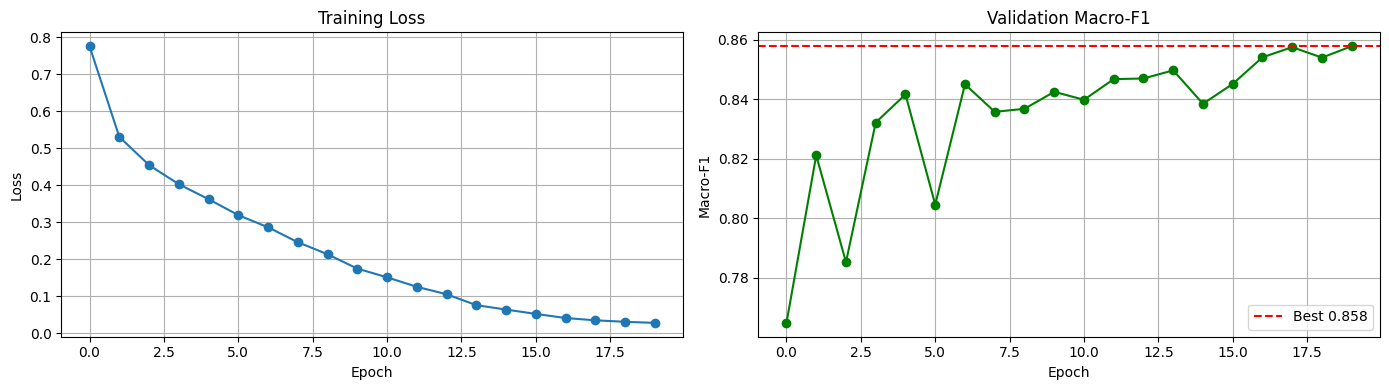

In [39]:
# Load best checkpoint + plot training curves
import os
if os.path.exists(save_path):
    try:
        ckpt = torch.load(save_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(save_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    best_val_f1 = float(ckpt.get('best_val_f1', best_val_f1))
    if 'training_history' in ckpt:
        training_history = ckpt['training_history']
    print(f"Loaded checkpoint from epoch {ckpt.get('epoch', 'N/A')} with best Val F1={best_val_f1:.4f}")
else:
    raise FileNotFoundError(f"Checkpoint not found: {save_path}. Run the training cell first.")

# Plot training history
if 'training_history' in globals() and len(training_history.get('train_loss', [])) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(training_history['train_loss'], marker='o')
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)
    ax2.plot(training_history['val_f1'], marker='o', color='green')
    ax2.axhline(y=best_val_f1, color='red', linestyle='--', label=f'Best {best_val_f1:.3f}')
    ax2.set_title('Validation Macro-F1')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Macro-F1')
    ax2.grid(True)
    ax2.legend()
    plt.tight_layout()
    plt.show()

Confusion matrix saved to: confusion_matrix.png


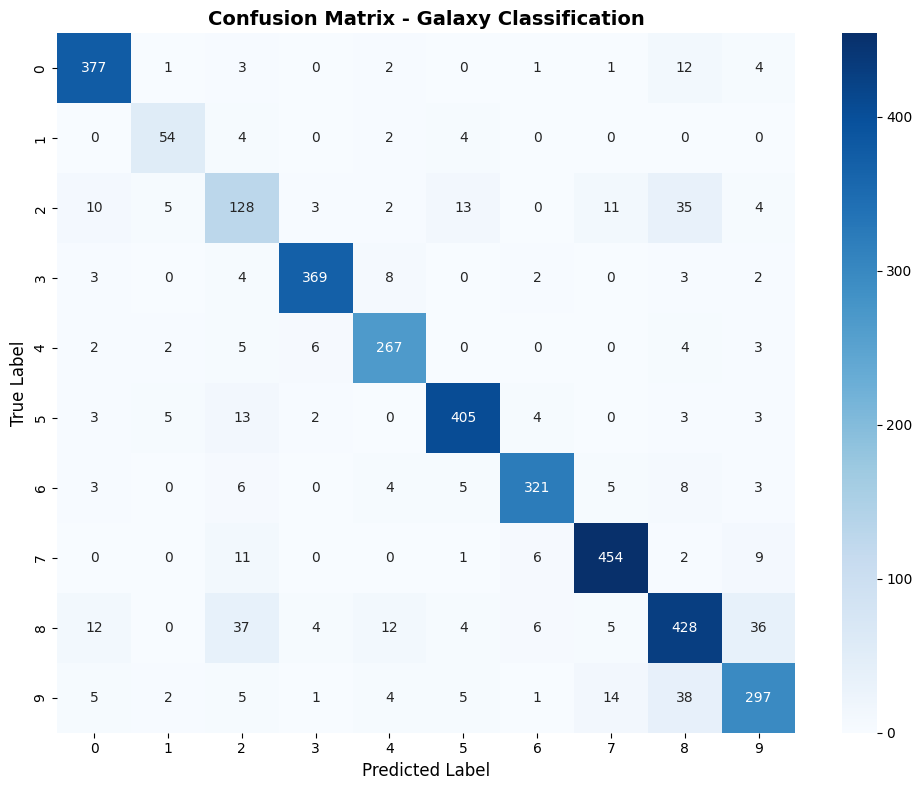

Confusion Matrix:
 [[377   1   3   0   2   0   1   1  12   4]
 [  0  54   4   0   2   4   0   0   0   0]
 [ 10   5 128   3   2  13   0  11  35   4]
 [  3   0   4 369   8   0   2   0   3   2]
 [  2   2   5   6 267   0   0   0   4   3]
 [  3   5  13   2   0 405   4   0   3   3]
 [  3   0   6   0   4   5 321   5   8   3]
 [  0   0  11   0   0   1   6 454   2   9]
 [ 12   0  37   4  12   4   6   5 428  36]
 [  5   2   5   1   4   5   1  14  38 297]]


In [40]:
# 5) Evaluation: predictions + confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

val_preds, val_probs, val_targets = evaluate_model(model, val_loader, device)
cm = confusion_matrix(val_targets, val_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix - Galaxy Classification', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
print('Confusion matrix saved to: confusion_matrix.png')
plt.show()

print('Confusion Matrix:\n', cm)

Per-class metrics saved to: per_class_metrics.csv
 Class  Precision   Recall  F1-Score  Support
     0   0.908434 0.940150  0.924020      401
     1   0.782609 0.843750  0.812030       64
     2   0.592593 0.606635  0.599532      211
     3   0.958442 0.943734  0.951031      391
     4   0.887043 0.923875  0.905085      289
     5   0.926773 0.924658  0.925714      438
     6   0.941349 0.904225  0.922414      355
     7   0.926531 0.939959  0.933196      483
     8   0.803002 0.786765  0.794800      544
     9   0.822715 0.798387  0.810368      372

Macro metrics:
  macro_precision: 0.8549489369837417
  macro_recall: 0.8612137426044733
  macro_f1: 0.8578190072126141
Per-class metrics plot saved to: per_class_metrics.png


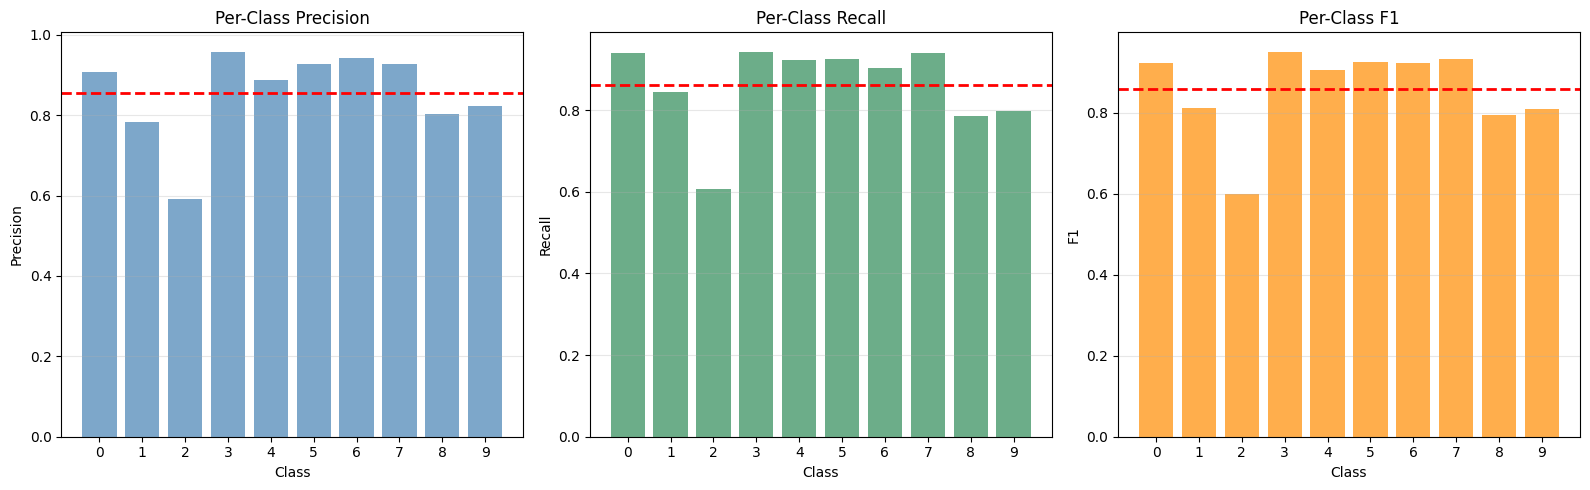

In [41]:
# Per-class metrics: Precision, Recall, F1 (+ plots, CSV)
import pandas as pd

precision, recall, f1, support = precision_recall_fscore_support(
    val_targets, val_preds, average=None, zero_division=0
 )
metrics_df = pd.DataFrame({
    'Class': range(NUM_CLASSES),
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support,
})
metrics_df.to_csv('per_class_metrics.csv', index=False)
print('Per-class metrics saved to: per_class_metrics.csv')
print(metrics_df.to_string(index=False))

macro_precision = float(np.mean(precision))
macro_recall = float(np.mean(recall))
macro_f1 = float(np.mean(f1))
print('\nMacro metrics:')
print('  macro_precision:', macro_precision)
print('  macro_recall:', macro_recall)
print('  macro_f1:', macro_f1)

# Plot per-class metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].bar(range(NUM_CLASSES), precision, color='steelblue', alpha=0.7)
axes[0].axhline(y=macro_precision, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Per-Class Precision')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Precision')
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(NUM_CLASSES), recall, color='seagreen', alpha=0.7)
axes[1].axhline(y=macro_recall, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Per-Class Recall')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Recall')
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(range(NUM_CLASSES), f1, color='darkorange', alpha=0.7)
axes[2].axhline(y=macro_f1, color='red', linestyle='--', linewidth=2)
axes[2].set_title('Per-Class F1')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('F1')
axes[2].set_xticks(range(NUM_CLASSES))
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
print('Per-class metrics plot saved to: per_class_metrics.png')
plt.show()

ROC-AUC per class:
  Class 0: 0.9941
  Class 1: 0.9868
  Class 2: 0.9037
  Class 3: 0.9975
  Class 4: 0.9940
  Class 5: 0.9919
  Class 6: 0.9890
  Class 7: 0.9947
  Class 8: 0.9704
  Class 9: 0.9788
Macro ROC-AUC: 0.9801
ROC-AUC plot saved to: roc_auc_scores.png


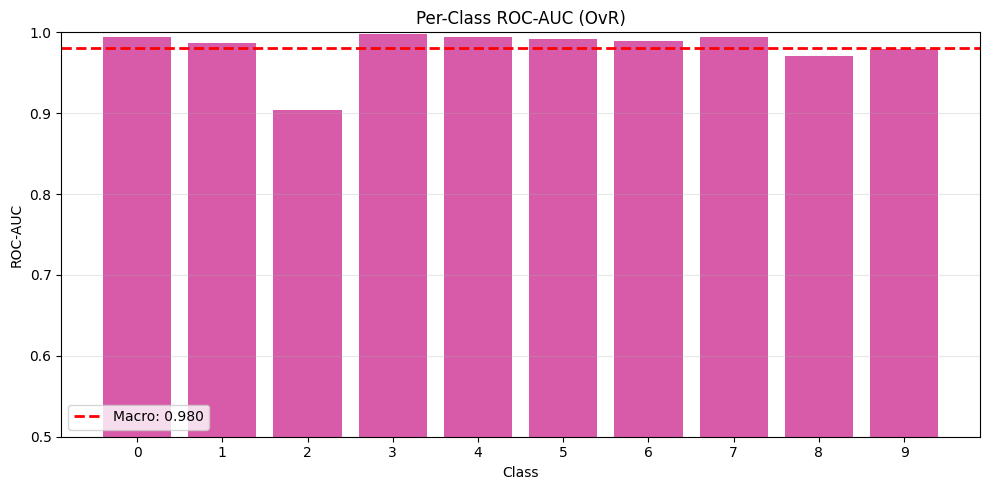

In [42]:
# ROC-AUC (One-vs-Rest multi-class)
from sklearn.metrics import roc_auc_score

try:
    y_onehot = np.zeros((len(val_targets), NUM_CLASSES), dtype=np.float32)
    y_onehot[np.arange(len(val_targets)), val_targets] = 1.0
    roc_auc_macro = roc_auc_score(y_onehot, val_probs, average='macro', multi_class='ovr')
    roc_auc_per_class = roc_auc_score(y_onehot, val_probs, average=None, multi_class='ovr')
    print('ROC-AUC per class:')
    for i, auc in enumerate(roc_auc_per_class):
        print(f'  Class {i}: {auc:.4f}')
    print(f'Macro ROC-AUC: {roc_auc_macro:.4f}')
    plt.figure(figsize=(10, 5))
    plt.bar(range(NUM_CLASSES), roc_auc_per_class, color='mediumvioletred', alpha=0.7)
    plt.axhline(y=roc_auc_macro, color='red', linestyle='--', linewidth=2, label=f'Macro: {roc_auc_macro:.3f}')
    plt.xlabel('Class')
    plt.ylabel('ROC-AUC')
    plt.title('Per-Class ROC-AUC (OvR)')
    plt.xticks(range(NUM_CLASSES))
    plt.ylim([0.5, 1.0])
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_auc_scores.png', dpi=150, bbox_inches='tight')
    print('ROC-AUC plot saved to: roc_auc_scores.png')
    plt.show()
except Exception as e:
    print('Error computing ROC-AUC:', repr(e))
    roc_auc_macro = float('nan')

In [43]:
# 5) Robustness Testing: Evaluate under corruptions
import io
from PIL import Image as PILImage

# Corruption functions
def apply_gaussian_blur(image, kernel_size=5):
    """Apply Gaussian blur to image"""
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

def apply_gaussian_noise(image, mean=0, std=15):
    """Apply Gaussian noise to image"""
    noise = np.random.normal(mean, std, image.shape).astype(np.float32)
    noisy = image.astype(np.float32) + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

def apply_jpeg_compression(image, quality=30):
    """Apply JPEG compression to image"""
    pil_img = PILImage.fromarray(image)
    buffer = io.BytesIO()
    pil_img.save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)
    compressed = PILImage.open(buffer)
    return np.array(compressed)

# Custom dataset wrapper for applying corruptions
class CorruptedDataset(Dataset):
    def __init__(self, hf_dataset, corruption_fn, transforms):
        self.ds = hf_dataset
        self.corruption_fn = corruption_fn
        self.transforms = transforms
    
    def __len__(self):
        return len(self.ds)
    
    def __getitem__(self, idx):
        item = self.ds[int(idx)]
        img = np.array(item['image'])
        # Apply corruption
        img = self.corruption_fn(img)
        # Apply standard transforms
        img = self.transforms(image=img)['image']
        label = int(item['label'])
        return img, label

print('Robustness testing functions defined')

Robustness testing functions defined


## 5. Robustness Testing

### Motivation
Real-world astronomical observations face various degradations:
- **Atmospheric turbulence**: Causes blur (seeing conditions)
- **Telescope tracking errors**: Motion blur
- **Detector noise**: CCD/CMOS sensor noise
- **Data compression**: FITS/JPEG compression for storage and transmission
- **Light pollution**: Background noise

Testing robustness ensures the model generalizes to imperfect observational conditions.

### Corruption Types

#### 1. Gaussian Blur (kernel_size=5)
**Simulates:** Atmospheric turbulence ("seeing"), optical aberrations, focus issues

**Physical interpretation:**
- Models point spread function (PSF) broadening
- Reduces fine spatial details (spiral arms, star-forming regions)
- Common in ground-based telescopes (vs space-based Hubble)

**Expected impact:** 
- Galaxies with fine structures (spirals, irregular) show larger F1 drops
- Smooth ellipticals are more robust

#### 2. Gaussian Noise (std=15)
**Simulates:** Detector read noise, photon shot noise, dark current

**Physical interpretation:**
- Low signal-to-noise ratio (SNR) observations
- Faint galaxies at high redshift
- Short exposure times

**Expected impact:**
- Uniform degradation across all classes
- Boundary features become harder to detect
- May affect all classes similarly

#### 3. JPEG Compression (quality=30)
**Simulates:** Data storage/transmission compression artifacts

**Physical interpretation:**
- Block artifacts from DCT compression
- Loss of high-frequency details
- Realistic for archival data or citizen science projects

**Expected impact:**
- Edge artifacts may confuse structural classification
- Texture-based features degraded
- Classes with detailed structures affected most

### Performance Drops: What They Reveal
- **Small drops (< 5%)**: Model is robust to this corruption
- **Moderate drops (5-15%)**: Model relies partially on features affected by corruption
- **Large drops (> 15%)**: Model heavily depends on corrupted features
- **Class-specific patterns**: Reveals which morphological features each class relies on

In [44]:
# Robustness baseline (clean validation metrics)
clean_preds, clean_probs, clean_targets = val_preds, val_probs, val_targets
clean_precision, clean_recall, clean_f1, _ = precision_recall_fscore_support(
    clean_targets, clean_preds, average=None, zero_division=0
 )
clean_macro_f1 = float(np.mean(clean_f1))
print('Clean validation baseline:')
print('  macro_f1:', clean_macro_f1)
print('  per-class f1:', clean_f1)

Clean validation baseline:
  macro_f1: 0.8578190072126141
  per-class f1: [0.92401961 0.81203008 0.59953162 0.95103093 0.90508475 0.92571429
 0.92241379 0.9331963  0.79480037 0.81036835]


In [45]:
# Robustness Test 1: Gaussian Blur
print('\n' + '='*70)
print('ROBUSTNESS TEST 1: GAUSSIAN BLUR (kernel_size=5)')
print('='*70)

blur_dataset = CorruptedDataset(ds_val, apply_gaussian_blur, val_transforms)
blur_loader = DataLoader(blur_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

blur_preds, blur_probs, blur_targets = evaluate_model(model, blur_loader, device)
_, _, blur_f1, _ = precision_recall_fscore_support(blur_targets, blur_preds, average=None, zero_division=0)
blur_macro_f1 = float(np.mean(blur_f1))
print(f'Blur macro_f1: {blur_macro_f1:.4f} (drop: {clean_macro_f1 - blur_macro_f1:.4f})')


ROBUSTNESS TEST 1: GAUSSIAN BLUR (kernel_size=5)
Blur macro_f1: 0.8533 (drop: 0.0046)


In [46]:
# Robustness Test 2: Gaussian Noise
print('\n' + '='*70)
print('ROBUSTNESS TEST 2: GAUSSIAN NOISE (std=15)')
print('='*70)

noise_dataset = CorruptedDataset(ds_val, apply_gaussian_noise, val_transforms)
noise_loader = DataLoader(noise_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

noise_preds, noise_probs, noise_targets = evaluate_model(model, noise_loader, device)
_, _, noise_f1, _ = precision_recall_fscore_support(noise_targets, noise_preds, average=None, zero_division=0)
noise_macro_f1 = float(np.mean(noise_f1))
print(f'Noise macro_f1: {noise_macro_f1:.4f} (drop: {clean_macro_f1 - noise_macro_f1:.4f})')


ROBUSTNESS TEST 2: GAUSSIAN NOISE (std=15)
Noise macro_f1: 0.8357 (drop: 0.0221)


In [47]:
# Robustness Test 3: JPEG Compression
print('\n' + '='*70)
print('ROBUSTNESS TEST 3: JPEG COMPRESSION (quality=30)')
print('='*70)

jpeg_dataset = CorruptedDataset(ds_val, apply_jpeg_compression, val_transforms)
jpeg_loader = DataLoader(jpeg_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

jpeg_preds, jpeg_probs, jpeg_targets = evaluate_model(model, jpeg_loader, device)
_, _, jpeg_f1, _ = precision_recall_fscore_support(jpeg_targets, jpeg_preds, average=None, zero_division=0)
jpeg_macro_f1 = float(np.mean(jpeg_f1))
print(f'JPEG macro_f1: {jpeg_macro_f1:.4f} (drop: {clean_macro_f1 - jpeg_macro_f1:.4f})')


ROBUSTNESS TEST 3: JPEG COMPRESSION (quality=30)
JPEG macro_f1: 0.8366 (drop: 0.0212)


## 4. Model Evaluation

### Metrics Overview
**Confusion Matrix** - Visualizes which galaxy types are confused with each other. Off-diagonal elements indicate systematic misclassifications.

**Per-Class Metrics:**
- **Precision**: Of all galaxies predicted as class X, what fraction are actually class X? (Important when false positives are costly)
- **Recall**: Of all true class X galaxies, what fraction did we correctly identify? (Important when false negatives are costly)
- **F1-Score**: Harmonic mean of precision and recall, balanced measure of performance

**Macro-F1**: Average F1 across all classes (treats each class equally, regardless of sample size)

**ROC-AUC (One-vs-Rest)**: Measures how well the model separates each class from all others. Values close to 1.0 indicate excellent discrimination.

### Expected Patterns
- **Spiral galaxies** (if present) might be confused with barred spirals due to similar structures
- **Elliptical galaxies** are typically easier to classify due to distinct smooth morphology
- **Irregular galaxies** may show lower performance due to high intra-class variation
- **Edge-on galaxies** might be challenging due to limited visible features

Robustness summary saved to: robustness_summary.csv
Corruption Type  Macro-F1  F1 Drop   Drop %
          Clean  0.857819 0.000000 0.000000
           Blur  0.853258 0.004561 0.531731
          Noise  0.835729 0.022090 2.575100
           JPEG  0.836607 0.021212 2.472745
Robustness comparison plot saved to: robustness_comparison.png


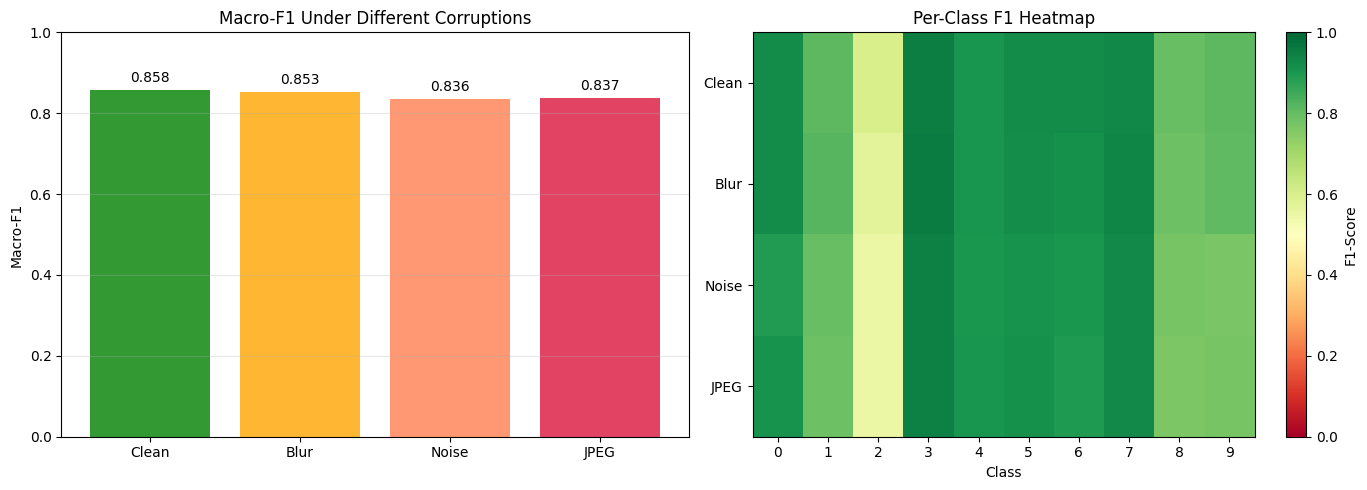

In [48]:
# Robustness comparison plots + CSV summary
import pandas as pd

corruption_types = ['Clean', 'Blur', 'Noise', 'JPEG']
macro_f1_scores = [clean_macro_f1, blur_macro_f1, noise_macro_f1, jpeg_macro_f1]

robustness_summary = pd.DataFrame({
    'Corruption Type': corruption_types,
    'Macro-F1': macro_f1_scores,
    'F1 Drop': [0.0, clean_macro_f1 - blur_macro_f1, clean_macro_f1 - noise_macro_f1, clean_macro_f1 - jpeg_macro_f1],
    'Drop %': [0.0, 100*(clean_macro_f1 - blur_macro_f1)/max(1e-8, clean_macro_f1),
              100*(clean_macro_f1 - noise_macro_f1)/max(1e-8, clean_macro_f1),
              100*(clean_macro_f1 - jpeg_macro_f1)/max(1e-8, clean_macro_f1)],
})
robustness_summary.to_csv('robustness_summary.csv', index=False)
print('Robustness summary saved to: robustness_summary.csv')
print(robustness_summary.to_string(index=False))

# Visualize robustness comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_bar = ['green', 'orange', 'coral', 'crimson']
axes[0].bar(corruption_types, macro_f1_scores, color=colors_bar, alpha=0.8)
axes[0].set_ylabel('Macro-F1')
axes[0].set_title('Macro-F1 Under Different Corruptions')
axes[0].set_ylim([0, 1.0])
axes[0].grid(axis='y', alpha=0.3)
for i, score in enumerate(macro_f1_scores):
    axes[0].text(i, score + 0.02, f'{score:.3f}', ha='center')

f1_comparison = np.array([clean_f1, blur_f1, noise_f1, jpeg_f1])
im = axes[1].imshow(f1_comparison, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
axes[1].set_yticks(range(4))
axes[1].set_yticklabels(corruption_types)
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].set_xlabel('Class')
axes[1].set_title('Per-Class F1 Heatmap')
plt.colorbar(im, ax=axes[1], label='F1-Score')
plt.tight_layout()
plt.savefig('robustness_comparison.png', dpi=150, bbox_inches='tight')
print('Robustness comparison plot saved to: robustness_comparison.png')
plt.show()

In [49]:
# Final evaluation summary (safe: runs after training+evaluation)
print('\n' + '=' * 70)
print('FINAL EVALUATION SUMMARY')
print('=' * 70)
print(f'Best Validation Macro-F1:     {best_val_f1:.4f}')
print(f'Validation Macro-F1:          {macro_f1:.4f}')
print(f'Validation Macro Precision:   {macro_precision:.4f}')
print(f'Validation Macro Recall:      {macro_recall:.4f}')
print(f'Validation Macro ROC-AUC:     {roc_auc_macro:.4f}')
print('=' * 70)
print('\nSaved artifacts:')
print('  - best_model.pth')
print('  - confusion_matrix.png')
print('  - per_class_metrics.csv')
print('  - per_class_metrics.png')
print('  - roc_auc_scores.png')
print('  - robustness_summary.csv')
print('  - robustness_comparison.png')
print('=' * 70)


FINAL EVALUATION SUMMARY
Best Validation Macro-F1:     0.8578
Validation Macro-F1:          0.8578
Validation Macro Precision:   0.8549
Validation Macro Recall:      0.8612
Validation Macro ROC-AUC:     0.9801

Saved artifacts:
  - best_model.pth
  - confusion_matrix.png
  - per_class_metrics.csv
  - per_class_metrics.png
  - roc_auc_scores.png
  - robustness_summary.csv
  - robustness_comparison.png


## 3. Training Strategy

### Loss Function
**Weighted Cross-Entropy Loss** - Uses computed class weights to handle imbalanced data. Classes with fewer samples receive higher loss weights, forcing the model to pay more attention to minority classes.

### Optimization
- **AdamW optimizer**: Adam with decoupled weight decay (better generalization)
- **Learning rate**: 1e-4 (conservative for fine-tuning pretrained models)
- **Weight decay**: 1e-4 (L2 regularization to prevent overfitting)

### Learning Rate Scheduling
**Cosine Annealing** - Gradually reduces learning rate following a cosine curve. This allows:
- Fast initial learning with higher LR
- Fine-grained refinement as LR approaches zero
- Smooth convergence without sudden drops

### Mixed Precision Training
Uses PyTorch's Automatic Mixed Precision (AMP) with `autocast` and `GradScaler`:
- **Faster training**: FP16 operations are 2-3× faster on modern GPUs
- **Lower memory**: Allows larger batch sizes
- **Maintained accuracy**: Critical operations still use FP32

### Early Stopping
Monitors **validation macro-F1** (not loss or accuracy) because:
- **Macro-F1** treats all classes equally, crucial for imbalanced datasets
- Prevents overfitting by stopping when validation performance plateaus
- Patience=5 epochs allows for noise in validation metrics